In [1]:
import pandas as pd
import numpy as np
import random
import os
from datetime import datetime

# Set seed for reproducibility
np.random.seed(42)
random.seed(42)

print("=" * 55)
print("SLIIT Synthetic Dataset Generator")
print("R26-IT-059 | IT22215710 | Karunarathne D C")
print("=" * 55)
print("\nLibraries imported successfully!")

SLIIT Synthetic Dataset Generator
R26-IT-059 | IT22215710 | Karunarathne D C

Libraries imported successfully!


In [2]:
# ─────────────────────────────────────────
# SLIIT SEMESTER STRUCTURE
# ─────────────────────────────────────────

# SLIIT modules (realistic IT faculty codes)
MODULES = {
    'IT3080': 'Machine Learning',
    'IT3070': 'Software Engineering',
    'IT3060': 'Database Systems',
    'IT3050': 'Computer Networks',
    'IT3040': 'Research Methods'
}

# Semester structure
TOTAL_WEEKS = 15
TOTAL_STUDENTS = 500

# Academic calendar
ACADEMIC_CALENDAR = {
    'orientation_weeks': [1],
    'normal_weeks': list(range(2, 9)),
    'mid_exam_week': [9],
    'post_mid_weeks': [10, 11],
    'assignment_rush_weeks': [12, 13],
    'final_exam_prep_week': [14],
    'final_exam_week': [15],
    'holiday_weeks': []
}

# Student types and proportions
STUDENT_TYPES = {
    'NORMAL':       250,  # 50%
    'BURNOUT':      100,  # 20%
    'STRUGGLING':    75,  # 15%
    'LATE_BURNOUT':  75   # 15%
}

print("SLIIT Structure Defined!")
print(f"\nModules: {len(MODULES)}")
for code, name in MODULES.items():
    print(f"  {code}: {name}")

print(f"\nTotal Students: {TOTAL_STUDENTS}")
print(f"Total Weeks:    {TOTAL_WEEKS}")
print(f"\nStudent Types:")
for stype, count in STUDENT_TYPES.items():
    pct = count/TOTAL_STUDENTS*100
    print(f"  {stype}: {count} students ({pct:.0f}%)")

print(f"\nAcademic Calendar:")
print(f"  Orientation:      Week 1")
print(f"  Normal:           Weeks 2-8")
print(f"  Mid Exam:         Week 9")
print(f"  Post Mid:         Weeks 10-11")
print(f"  Assignment Rush:  Weeks 12-13")
print(f"  Final Exam Prep:  Week 14")
print(f"  Finals:           Week 15")

SLIIT Structure Defined!

Modules: 5
  IT3080: Machine Learning
  IT3070: Software Engineering
  IT3060: Database Systems
  IT3050: Computer Networks
  IT3040: Research Methods

Total Students: 500
Total Weeks:    15

Student Types:
  NORMAL: 250 students (50%)
  BURNOUT: 100 students (20%)
  STRUGGLING: 75 students (15%)
  LATE_BURNOUT: 75 students (15%)

Academic Calendar:
  Orientation:      Week 1
  Normal:           Weeks 2-8
  Mid Exam:         Week 9
  Post Mid:         Weeks 10-11
  Assignment Rush:  Weeks 12-13
  Final Exam Prep:  Week 14
  Finals:           Week 15


In [3]:
# Sri Lankan student names (realistic)
FIRST_NAMES = [
    'Kavindu', 'Dulshan', 'Tharaka', 'Sachini',
    'Nimasha', 'Rasika', 'Dinuka', 'Malsha',
    'Chanuka', 'Sithum', 'Kavindi', 'Thisara',
    'Sanduni', 'Lahiru', 'Piyumi', 'Ravindu',
    'Thilini', 'Kasun', 'Nadeesha', 'Buddhika',
    'Chamodi', 'Isuru', 'Hasini', 'Nuwan',
    'Dilani', 'Rukshan', 'Amaya', 'Dhanuka',
    'Sewwandi', 'Pasindu', 'Hiruni', 'Gayan',
    'Oshadi', 'Malindu', 'Chathurika', 'Ashen',
    'Ridma', 'Supun', 'Nimesha', 'Charith'
]

LAST_NAMES = [
    'Perera', 'Silva', 'Fernando', 'Dissanayake',
    'Jayasinghe', 'Wickramasinghe', 'Rajapaksa',
    'Bandara', 'Senanayake', 'Gunasekara',
    'Karunarathne', 'Weerasinghe', 'Pathirana',
    'Mendis', 'Amarasinghe', 'Rathnayake',
    'Liyanage', 'Jayawardena', 'Madushanka',
    'Herath', 'Kumara', 'Wijesinghe', 'Sankha',
    'Ranasinghe', 'Fonseka', 'Gunawardena'
]

# Generate student list
def generate_students(n=500):
    students = []
    used_ids = set()
    used_names = set()

    for i in range(n):
        # Generate unique IT number
        while True:
            it_num = f"IT{random.randint(22000000, 22999999)}"
            if it_num not in used_ids:
                used_ids.add(it_num)
                break

        # Generate unique name
        while True:
            first = random.choice(FIRST_NAMES)
            last = random.choice(LAST_NAMES)
            name = f"{first} {last}"
            if name not in used_names:
                used_names.add(name)
                break

        # Assign student type
        if i < 250:
            stype = 'NORMAL'
        elif i < 350:
            stype = 'BURNOUT'
        elif i < 425:
            stype = 'STRUGGLING'
        else:
            stype = 'LATE_BURNOUT'

        students.append({
            'student_id': it_num,
            'student_name': name,
            'student_type': stype,
            'year': 3,
            'batch': '2022'
        })

    return pd.DataFrame(students)

students_df = generate_students(TOTAL_STUDENTS)

print(f"Students generated: {len(students_df):,}")
print(f"\nStudent type distribution:")
print(students_df['student_type'].value_counts())
print(f"\nSample students:")
print(students_df.head(8))

Students generated: 500

Student type distribution:
student_type
NORMAL          250
BURNOUT         100
STRUGGLING       75
LATE_BURNOUT     75
Name: count, dtype: int64

Sample students:
   student_id         student_name student_type  year batch
0  IT22670487        Malsha Perera       NORMAL     3  2022
1  IT22777572        Kasun Bandara       NORMAL     3  2022
2  IT22234053   Chanuka Ranasinghe       NORMAL     3  2022
3  IT22107473  Chathurika Fernando       NORMAL     3  2022
4  IT22619176        Dhanuka Silva       NORMAL     3  2022
5  IT22031244     Rasika Rajapaksa       NORMAL     3  2022
6  IT22243962        Oshadi Herath       NORMAL     3  2022
7  IT22027824      Ashen Rajapaksa       NORMAL     3  2022


In [4]:
# ─────────────────────────────────────────
# BEHAVIORAL PATTERNS PER STUDENT TYPE
# ─────────────────────────────────────────

def get_weekly_behavior(student_type, week, module_code):
    """
    Generate realistic LMS behavioral data
    based on student type and week number
    """
    
    # Base noise function
    def noise(val, pct=0.2):
        return max(0, val * (1 + np.random.uniform(-pct, pct)))

    # ── NORMAL STUDENT ──────────────────
    if student_type == 'NORMAL':
        if week == 1:  # Orientation week
            clicks = noise(60, 0.3)
            active_days = noise(3, 0.3)
            forum = noise(5, 0.4)
            resources = noise(8, 0.3)
            quiz = noise(1, 0.5)
            latency = np.random.randint(-7, 3)
            video_views = noise(3, 0.4)
        elif week == 9:  # Mid exam week
            clicks = noise(200, 0.2)
            active_days = noise(7, 0.1)
            forum = noise(8, 0.3)
            resources = noise(40, 0.2)
            quiz = noise(8, 0.3)
            latency = np.random.randint(-5, 2)
            video_views = noise(12, 0.3)
        elif week in [14, 15]:  # Final exam
            clicks = noise(220, 0.2)
            active_days = noise(7, 0.1)
            forum = noise(6, 0.3)
            resources = noise(45, 0.2)
            quiz = noise(10, 0.3)
            latency = np.random.randint(-3, 2)
            video_views = noise(15, 0.2)
        elif week in [12, 13]:  # Assignment rush
            clicks = noise(180, 0.2)
            active_days = noise(6, 0.2)
            forum = noise(15, 0.3)
            resources = noise(30, 0.2)
            quiz = noise(5, 0.3)
            latency = np.random.randint(-10, 5)
            video_views = noise(8, 0.3)
        else:  # Normal weeks
            clicks = noise(120, 0.25)
            active_days = noise(5, 0.2)
            forum = noise(10, 0.3)
            resources = noise(20, 0.25)
            quiz = noise(3, 0.4)
            latency = np.random.randint(-7, 3)
            video_views = noise(6, 0.3)

    # ── BURNOUT STUDENT ─────────────────
    elif student_type == 'BURNOUT':
        if week <= 5:  # Normal phase
            clicks = noise(115, 0.25)
            active_days = noise(5, 0.2)
            forum = noise(9, 0.3)
            resources = noise(18, 0.25)
            quiz = noise(3, 0.4)
            latency = np.random.randint(-7, 3)
            video_views = noise(5, 0.3)
        elif week == 6:  # Start dropping
            clicks = noise(80, 0.3)
            active_days = noise(3, 0.3)
            forum = noise(4, 0.4)
            resources = noise(10, 0.3)
            quiz = noise(1, 0.5)
            latency = np.random.randint(-2, 8)
            video_views = noise(2, 0.5)
        elif week == 7:  # Clear drop
            clicks = noise(45, 0.3)
            active_days = noise(2, 0.4)
            forum = noise(1, 0.6)
            resources = noise(5, 0.4)
            quiz = noise(0.5, 0.6)
            latency = np.random.randint(0, 12)
            video_views = noise(1, 0.6)
        elif week == 8:  # Severe drop
            clicks = noise(20, 0.4)
            active_days = noise(1, 0.5)
            forum = 0
            resources = noise(2, 0.5)
            quiz = 0
            latency = np.random.randint(5, 15)
            video_views = 0
        elif week == 9:  # Mid exam - slight recovery
            clicks = noise(40, 0.4)
            active_days = noise(2, 0.4)
            forum = 0
            resources = noise(8, 0.4)
            quiz = noise(2, 0.5)
            latency = np.random.randint(3, 10)
            video_views = noise(1, 0.6)
        else:  # Fully burnt out
            clicks = noise(10, 0.5)
            active_days = noise(1, 0.6)
            forum = 0
            resources = noise(1, 0.6)
            quiz = 0
            latency = np.random.randint(10, 30)
            video_views = 0

    # ── STRUGGLING STUDENT ──────────────
    elif student_type == 'STRUGGLING':
        # Always low but consistent - no sudden change
        if week == 9:  # Mid exam
            clicks = noise(50, 0.3)
            active_days = noise(3, 0.3)
            forum = noise(2, 0.5)
            resources = noise(12, 0.3)
            quiz = noise(3, 0.4)
            latency = np.random.randint(0, 10)
            video_views = noise(3, 0.4)
        elif week in [14, 15]:
            clicks = noise(60, 0.3)
            active_days = noise(3, 0.3)
            forum = noise(1, 0.5)
            resources = noise(15, 0.3)
            quiz = noise(4, 0.4)
            latency = np.random.randint(0, 8)
            video_views = noise(4, 0.4)
        else:
            clicks = noise(25, 0.3)
            active_days = noise(2, 0.3)
            forum = noise(1, 0.5)
            resources = noise(5, 0.4)
            quiz = noise(1, 0.5)
            latency = np.random.randint(2, 12)
            video_views = noise(1, 0.5)

    # ── LATE BURNOUT STUDENT ────────────
    elif student_type == 'LATE_BURNOUT':
        if week <= 9:  # Very active early
            clicks = noise(160, 0.2)
            active_days = noise(6, 0.15)
            forum = noise(15, 0.25)
            resources = noise(30, 0.2)
            quiz = noise(5, 0.3)
            latency = np.random.randint(-10, 0)
            video_views = noise(10, 0.25)
        elif week == 10:  # Sudden crash
            clicks = noise(40, 0.4)
            active_days = noise(2, 0.4)
            forum = noise(2, 0.5)
            resources = noise(5, 0.4)
            quiz = noise(1, 0.5)
            latency = np.random.randint(5, 15)
            video_views = noise(1, 0.5)
        else:  # Stays low
            clicks = noise(15, 0.5)
            active_days = noise(1, 0.5)
            forum = 0
            resources = noise(2, 0.5)
            quiz = 0
            latency = np.random.randint(8, 25)
            video_views = 0

    return {
        'weekly_clicks': max(0, int(clicks)),
        'active_days': max(0, min(7, int(active_days))),
        'forum_posts': max(0, int(forum)),
        'resource_views': max(0, int(resources)),
        'quiz_attempts': max(0, int(quiz)),
        'submission_latency': int(latency),
        'lecture_video_views': max(0, int(video_views))
    }

print("Behavioral patterns defined!")
print("\nTesting patterns:")
for stype in ['NORMAL', 'BURNOUT', 'STRUGGLING', 'LATE_BURNOUT']:
    b = get_weekly_behavior(stype, 7, 'IT3080')
    print(f"\n{stype} at week 7:")
    for k, v in b.items():
        print(f"  {k}: {v}")

Behavioral patterns defined!

Testing patterns:

NORMAL at week 7:
  weekly_clicks: 112
  active_days: 5
  forum_posts: 11
  resource_views: 20
  quiz_attempts: 2
  submission_latency: -5
  lecture_video_views: 4

BURNOUT at week 7:
  weekly_clicks: 43
  active_days: 1
  forum_posts: 0
  resource_views: 5
  quiz_attempts: 0
  submission_latency: 7
  lecture_video_views: 1

STRUGGLING at week 7:
  weekly_clicks: 20
  active_days: 1
  forum_posts: 0
  resource_views: 4
  quiz_attempts: 1
  submission_latency: 10
  lecture_video_views: 0

LATE_BURNOUT at week 7:
  weekly_clicks: 167
  active_days: 5
  forum_posts: 13
  resource_views: 28
  quiz_attempts: 4
  submission_latency: -8
  lecture_video_views: 9


In [5]:
# ─────────────────────────────────────────
# GENERATE FULL LMS INTERACTION DATASET
# ─────────────────────────────────────────

print("Generating full SLIIT synthetic dataset...")
print("This may take a moment...")

all_records = []

for _, student in students_df.iterrows():
    student_id = student['student_id']
    student_type = student['student_type']

    for module_code in MODULES.keys():
        for week in range(1, TOTAL_WEEKS + 1):

            # Get behavioral data for this week
            behavior = get_weekly_behavior(
                student_type, week, module_code
            )

            # Calculate content diversity
            active_features = sum([
                behavior['forum_posts'] > 0,
                behavior['resource_views'] > 0,
                behavior['quiz_attempts'] > 0,
                behavior['lecture_video_views'] > 0,
                behavior['weekly_clicks'] > 50
            ])
            content_diversity = max(1, active_features)

            # Calculate late submission flag
            late_submission = 1 if behavior[
                'submission_latency'
            ] > 0 else 0

            # Determine at-risk label
            if student_type == 'NORMAL':
                at_risk = 0
            elif student_type == 'STRUGGLING':
                at_risk = 0
            elif student_type == 'BURNOUT':
                at_risk = 1
            elif student_type == 'LATE_BURNOUT':
                at_risk = 1

            # Determine week type
            if week == 1:
                week_type = 'orientation'
            elif week in [2, 3]:
                week_type = 'baseline'
            elif week == 9:
                week_type = 'mid_exam'
            elif week in [14, 15]:
                week_type = 'final_exam'
            else:
                week_type = 'normal'

            record = {
                'student_id': student_id,
                'student_name': student['student_name'],
                'student_type': student_type,
                'module_code': module_code,
                'module_name': MODULES[module_code],
                'week': week,
                'week_type': week_type,
                'weekly_clicks': behavior['weekly_clicks'],
                'active_days': behavior['active_days'],
                'forum_posts': behavior['forum_posts'],
                'resource_views': behavior['resource_views'],
                'quiz_attempts': behavior['quiz_attempts'],
                'submission_latency': behavior['submission_latency'],
                'lecture_video_views': behavior['lecture_video_views'],
                'content_diversity': content_diversity,
                'late_submission': late_submission,
                'at_risk': at_risk
            }

            all_records.append(record)

# Create dataframe
sliit_df = pd.DataFrame(all_records)

print(f"Dataset generated!")
print(f"\nShape: {sliit_df.shape}")
print(f"Total records: {len(sliit_df):,}")
print(f"Students: {sliit_df['student_id'].nunique():,}")
print(f"Modules: {sliit_df['module_code'].nunique()}")
print(f"Weeks: {sliit_df['week'].nunique()}")
print(f"\nAt-risk distribution:")
print(sliit_df.drop_duplicates('student_id')['at_risk'].value_counts())
print(f"\nAt-risk rate: {sliit_df['at_risk'].mean()*100:.1f}%")
print(f"\nSample:")
print(sliit_df.head())

Generating full SLIIT synthetic dataset...
This may take a moment...
Dataset generated!

Shape: (37500, 17)
Total records: 37,500
Students: 500
Modules: 5
Weeks: 15

At-risk distribution:
at_risk
0    325
1    175
Name: count, dtype: int64

At-risk rate: 35.0%

Sample:
   student_id   student_name student_type module_code       module_name  week  \
0  IT22670487  Malsha Perera       NORMAL      IT3080  Machine Learning     1   
1  IT22670487  Malsha Perera       NORMAL      IT3080  Machine Learning     2   
2  IT22670487  Malsha Perera       NORMAL      IT3080  Machine Learning     3   
3  IT22670487  Malsha Perera       NORMAL      IT3080  Machine Learning     4   
4  IT22670487  Malsha Perera       NORMAL      IT3080  Machine Learning     5   

     week_type  weekly_clicks  active_days  forum_posts  resource_views  \
0  orientation             77            2            6               8   
1     baseline            147            5            8              15   
2     baseline    

Verifying behavioral patterns...


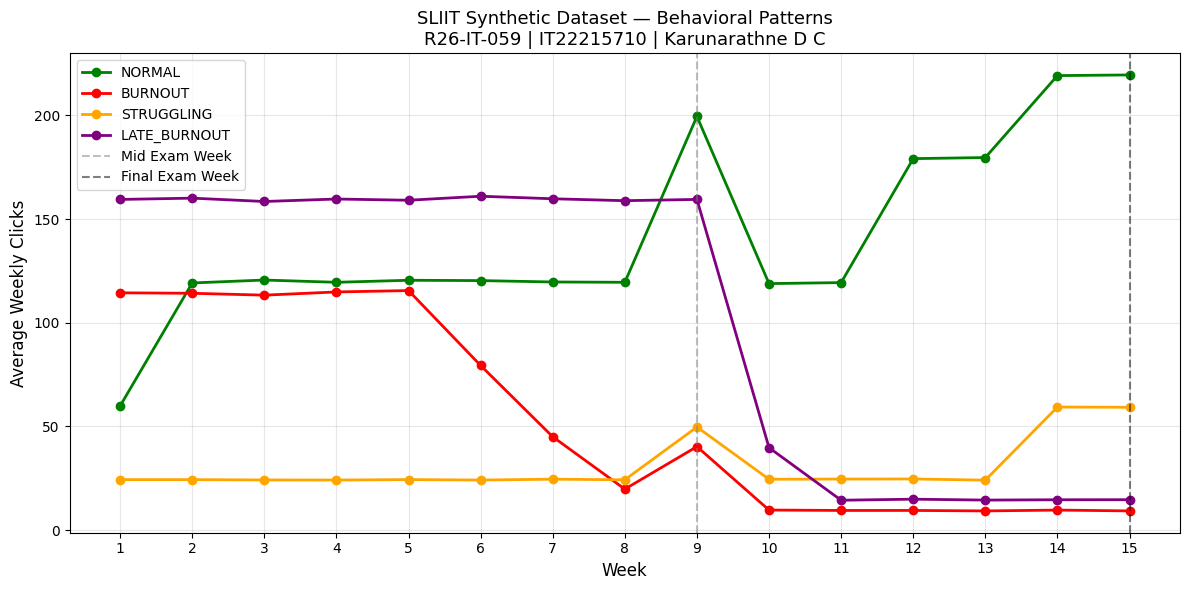


Pattern verification:

NORMAL:
  Week 3:  121 clicks
  Week 8:  119 clicks
  Week 12: 179 clicks

BURNOUT:
  Week 3:  113 clicks
  Week 8:  20 clicks
  Week 12: 10 clicks

STRUGGLING:
  Week 3:  24 clicks
  Week 8:  24 clicks
  Week 12: 25 clicks

LATE_BURNOUT:
  Week 3:  158 clicks
  Week 8:  159 clicks
  Week 12: 15 clicks


In [6]:
import matplotlib.pyplot as plt

print("Verifying behavioral patterns...")

# Average clicks per week by student type
weekly_avg = sliit_df.groupby(
    ['student_type', 'week']
)['weekly_clicks'].mean().reset_index()

plt.figure(figsize=(12, 6))

colors = {
    'NORMAL': 'green',
    'BURNOUT': 'red',
    'STRUGGLING': 'orange',
    'LATE_BURNOUT': 'purple'
}

for stype in ['NORMAL', 'BURNOUT', 
              'STRUGGLING', 'LATE_BURNOUT']:
    data = weekly_avg[
        weekly_avg['student_type'] == stype
    ]
    plt.plot(
        data['week'],
        data['weekly_clicks'],
        marker='o',
        color=colors[stype],
        linewidth=2,
        label=stype
    )

# Mark important weeks
plt.axvline(x=9, color='gray', 
            linestyle='--', alpha=0.5,
            label='Mid Exam Week')
plt.axvline(x=15, color='black',
            linestyle='--', alpha=0.5,
            label='Final Exam Week')

plt.xlabel('Week', fontsize=12)
plt.ylabel('Average Weekly Clicks', fontsize=12)
plt.title(
    'SLIIT Synthetic Dataset — Behavioral Patterns\n'
    'R26-IT-059 | IT22215710 | Karunarathne D C',
    fontsize=13
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 16))
plt.tight_layout()
plt.savefig(
    '../results/figures/sliit_behavioral_patterns.png',
    dpi=150
)
plt.show()

print("\nPattern verification:")
for stype in ['NORMAL', 'BURNOUT', 
              'STRUGGLING', 'LATE_BURNOUT']:
    week3 = sliit_df[
        (sliit_df['student_type'] == stype) &
        (sliit_df['week'] == 3)
    ]['weekly_clicks'].mean()
    week8 = sliit_df[
        (sliit_df['student_type'] == stype) &
        (sliit_df['week'] == 8)
    ]['weekly_clicks'].mean()
    week12 = sliit_df[
        (sliit_df['student_type'] == stype) &
        (sliit_df['week'] == 12)
    ]['weekly_clicks'].mean()
    print(f"\n{stype}:")
    print(f"  Week 3:  {week3:.0f} clicks")
    print(f"  Week 8:  {week8:.0f} clicks")
    print(f"  Week 12: {week12:.0f} clicks")

In [7]:
# Save all CSV files
OUTPUT_PATH = "../data/raw/"

# Main dataset
sliit_df.to_csv(
    OUTPUT_PATH + "sliit_lms_data.csv",
    index=False
)

# Student info separately
student_info = sliit_df[[
    'student_id', 'student_name',
    'student_type', 'at_risk'
]].drop_duplicates('student_id')

student_info.to_csv(
    OUTPUT_PATH + "sliit_student_info.csv",
    index=False
)

# Module info
module_info = pd.DataFrame([
    {'module_code': code, 'module_name': name}
    for code, name in MODULES.items()
])
module_info.to_csv(
    OUTPUT_PATH + "sliit_modules.csv",
    index=False
)

# Academic calendar
calendar_data = []
for week in range(1, TOTAL_WEEKS + 1):
    if week == 1:
        wtype = 'orientation'
    elif week in [2, 3]:
        wtype = 'baseline'
    elif week == 9:
        wtype = 'mid_exam'
    elif week in [14, 15]:
        wtype = 'final_exam'
    else:
        wtype = 'normal'

    calendar_data.append({
        'week': week,
        'week_type': wtype,
        'is_holiday': 0,
        'is_exam': 1 if wtype in [
            'mid_exam', 'final_exam'
        ] else 0
    })

calendar_df = pd.DataFrame(calendar_data)
calendar_df.to_csv(
    OUTPUT_PATH + "sliit_academic_calendar.csv",
    index=False
)

print("All files saved!")
print(f"\nFiles created:")
print(f"  sliit_lms_data.csv        → {len(sliit_df):,} records")
print(f"  sliit_student_info.csv    → {len(student_info):,} students")
print(f"  sliit_modules.csv         → {len(module_info)} modules")
print(f"  sliit_academic_calendar.csv → {len(calendar_df)} weeks")
print(f"\nDataset Summary:")
print(f"  Students:    {sliit_df['student_id'].nunique():,}")
print(f"  Modules:     {sliit_df['module_code'].nunique()}")
print(f"  Weeks:       {sliit_df['week'].nunique()}")
print(f"  Records:     {len(sliit_df):,}")
print(f"  At-risk:     35.0%")
print(f"  Features:    7 behavioral features")
print(f"\nReady for VAE training!")

All files saved!

Files created:
  sliit_lms_data.csv        → 37,500 records
  sliit_student_info.csv    → 500 students
  sliit_modules.csv         → 5 modules
  sliit_academic_calendar.csv → 15 weeks

Dataset Summary:
  Students:    500
  Modules:     5
  Weeks:       15
  Records:     37,500
  At-risk:     35.0%
  Features:    7 behavioral features

Ready for VAE training!
